# Transformers — PyTorch Pipeline

## Model: Transformer Encoder-Decoder + Encoder-Only (Translation + Classification)
- **Datasets**: Tatoeba EN→ES — 114K train / 14K val / 14K test, BPE tokenized (25 max) | AG News — 108K train / 12K val / 7.6K test, BPE tokenized (128 max)
- **Tasks**: Machine translation (direct comparison with Attention #15) + 4-class news classification
- **Framework showcase**: Full Transformer from scratch — self-attention, cross-attention, positional encoding, causal masking. No `nn.Transformer` or `nn.MultiheadAttention`.

## Evaluation Strategy
- **Translation metric**: BLEU-4 (BPE decoded back to words for fair comparison with #15 Bahdanau 0.3803)
- **Classification metric**: Accuracy + macro F1 (from-scratch vs fine-tuned DistilBERT)
- **Key experiments**: Vanilla vs training recipe impact, greedy vs beam search, from-scratch vs pre-trained gap
- **Visuals**: Positional encoding heatmap, multi-head attention grid, BLEU progression chart with #15 baseline

## Pipeline
1. Setup + load both datasets
2. Positional encoding (sinusoidal, visualization)
3. Vanilla Transformer (translation, from scratch, greedy decode)
4. Training recipe (warmup scheduler, label smoothing)
5. Beam search (no retraining, decode improvement)
6. Translation evaluation & comparison with #15
7. Per-length BLEU analysis
8. Encoder-only Transformer (AG News classification, from scratch)
9. Fine-tune DistilBERT (AG News, same dataset)
10. Classification evaluation (from-scratch vs fine-tuned)
11. Performance benchmarks (all variants)
12. Save results

In [1]:
# Step 1: Setup
"""
Load both datasets (translation + classification) and configure
all constants. Translation data uses BPE with shared 8K EN+ES vocab.
Classification data uses BPE with 16K English-only vocab.
Both use SentencePiece for encoding/decoding.
"""

import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import sentencepiece as spm

sys.path.insert(0, os.path.abspath('../..'))
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import save_results, add_result, print_comparison
from utils.attention_utils import compute_bleu, bleu_by_length
from utils.transformer_utils import create_pad_mask, create_causal_mask, compute_bleu_greedy, beam_search_decode

FRAMEWORK = 'PyTorch'
RANDOM_STATE = 113

# Translation hyperparameters
D_MODEL = 256
N_HEADS = 8                # d_k = 256/8 = 32 per head
N_ENCODER_LAYERS = 3
N_DECODER_LAYERS = 3
D_FF = 1024                # 4x d_model (paper standard)
DROPOUT = 0.1
BATCH_SIZE = 64
MAX_EPOCHS = 30
PATIENCE = 5
LABEL_SMOOTHING = 0.1      # Variant 2+
WARMUP_STEPS = 4000        # Variant 2+
BEAM_SIZE = 5              # Variant 3

RESULTS_DIR = 'results'

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("[1/12] SETUP")
print("=" * 60)
print(f"  Device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


# Translation data (Tatoeba EN→ES, BPE tokenized)
trans_dir = '../../data/processed/transformers_translation'

src_train = np.load(f'{trans_dir}/src_train.npy')
src_val = np.load(f'{trans_dir}/src_val.npy')
src_test = np.load(f'{trans_dir}/src_test.npy')
tgt_train = np.load(f'{trans_dir}/tgt_train.npy')
tgt_val = np.load(f'{trans_dir}/tgt_val.npy')
tgt_test = np.load(f'{trans_dir}/tgt_test.npy')

with open(f'{trans_dir}/preprocessing_info.json', 'r') as f:
    trans_meta = json.load(f)

# Load BPE model for decoding predictions back to text
sp_trans = spm.SentencePieceProcessor()
sp_trans.load(f'{trans_dir}/bpe.model')

TRANS_VOCAB_SIZE = trans_meta['bpe_vocab_size']
TRANS_MAX_LENGTH = trans_meta['max_length']
TRANS_PAD_IDX = trans_meta['special_tokens']['<pad>']
TRANS_BOS_IDX = trans_meta['special_tokens']['<s>']
TRANS_EOS_IDX = trans_meta['special_tokens']['</s>']

print(f"\n  --- Translation (Tatoeba EN→ES) ---")
print(f"  Vocab: {TRANS_VOCAB_SIZE:,} (shared BPE)")
print(f"  Max length: {TRANS_MAX_LENGTH} | PAD={TRANS_PAD_IDX} BOS={TRANS_BOS_IDX} EOS={TRANS_EOS_IDX}")
print(f"  Train: {src_train.shape[0]:,} | Val: {src_val.shape[0]:,} | Test: {src_test.shape[0]:,}")
print(f"  Shape: {src_train.shape}")

# Build translation DataLoader
trans_train_dataset = TensorDataset(
    torch.from_numpy(src_train).long(),
    torch.from_numpy(tgt_train).long()
)
trans_train_loader = DataLoader(trans_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

trans_val_src = torch.from_numpy(src_val).long().to(device)
trans_val_tgt = torch.from_numpy(tgt_val).long().to(device)
trans_test_src = torch.from_numpy(src_test).long().to(device)
trans_test_tgt = torch.from_numpy(tgt_test).long().to(device)


# Classification data (AG News, BPE tokenized)
cls_dir = '../../data/processed/transformers_classification'

X_train_cls = np.load(f'{cls_dir}/X_train.npy')
X_val_cls = np.load(f'{cls_dir}/X_val.npy')
X_test_cls = np.load(f'{cls_dir}/X_test.npy')
y_train_cls = np.load(f'{cls_dir}/y_train.npy')
y_val_cls = np.load(f'{cls_dir}/y_val.npy')
y_test_cls = np.load(f'{cls_dir}/y_test.npy')

with open(f'{cls_dir}/preprocessing_info.json', 'r') as f:
    cls_meta = json.load(f)

sp_cls = spm.SentencePieceProcessor()
sp_cls.load(f'{cls_dir}/bpe.model')

CLS_VOCAB_SIZE = cls_meta['bpe_vocab_size']
CLS_MAX_LENGTH = cls_meta['max_length']
CLS_PAD_IDX = cls_meta['special_tokens']['<pad>']
N_CLASSES = cls_meta['n_classes']
CLASS_NAMES = cls_meta['class_names']

print(f"\n  --- Classification (AG News) ---")
print(f"  Vocab: {CLS_VOCAB_SIZE:,} (English BPE)")
print(f"  Max length: {CLS_MAX_LENGTH} | Classes: {N_CLASSES}")
print(f"  Train: {X_train_cls.shape[0]:,} | Val: {X_val_cls.shape[0]:,} | Test: {X_test_cls.shape[0]:,}")
print(f"  Shape: {X_train_cls.shape}")
print(f"  Classes: {CLASS_NAMES}")

# Helper: decode BPE tokens back to text
def decode_bpe(token_ids, sp_model, stop_ids=None):
    # Decode BPE token IDs back to readable text, stopping at EOS/PAD
    ids = []
    for tid in token_ids:
        tid = int(tid)
        if stop_ids and tid in stop_ids:
            break
        if tid >= 4:  # skip special tokens (0-3)
            ids.append(tid)
    return sp_model.decode(ids)

# Verify decode works
sample_src = decode_bpe(src_train[0], sp_trans, stop_ids={TRANS_PAD_IDX})
sample_tgt = decode_bpe(tgt_train[0], sp_trans, stop_ids={TRANS_PAD_IDX})
print(f"\n  Decoded translation sample:")
print(f"    EN: {sample_src}")
print(f"    ES: {sample_tgt}")

sample_cls = decode_bpe(X_train_cls[0], sp_cls, stop_ids={CLS_PAD_IDX})
print(f"\n  Decoded classification sample:")
print(f"    Text: {sample_cls[:100]}...")
print(f"    Label: {y_train_cls[0]} ({CLASS_NAMES[str(y_train_cls[0])]})")

print(f"\n  Train batches (translation): {len(trans_train_loader)} (batch_size={BATCH_SIZE})")

os.makedirs(RESULTS_DIR, exist_ok=True)

[1/12] SETUP
  Device: cuda
  GPU: NVIDIA GeForce RTX 4090

  --- Translation (Tatoeba EN→ES) ---
  Vocab: 8,000 (shared BPE)
  Max length: 25 | PAD=0 BOS=1 EOS=2
  Train: 114,873 | Val: 14,359 | Test: 14,360
  Shape: (114873, 25)

  --- Classification (AG News) ---
  Vocab: 16,000 (English BPE)
  Max length: 128 | Classes: 4
  Train: 108,000 | Val: 12,000 | Test: 7,600
  Shape: (108000, 128)
  Classes: {'0': 'World', '1': 'Sports', '2': 'Business', '3': 'Sci/Tech'}

  Decoded translation sample:
    EN: i'm severely allergic to peanuts.
    ES: soy extremadamente alérgica a los cacahuates.

  Decoded classification sample:
    Text: fuel cell 's got the power for 3g handsets japanese mobile network operator ntt docomo announced on ...
    Label: 3 (Sci/Tech)

  Train batches (translation): 1795 (batch_size=64)


[2/12] POSITIONAL ENCODING


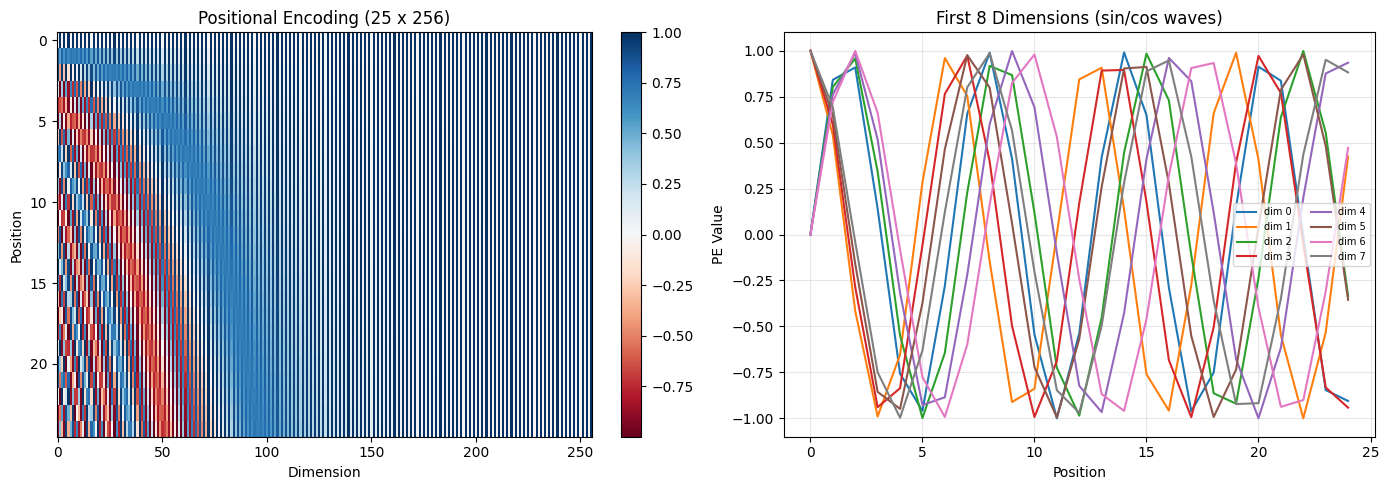


  Saved: results/positional_encoding.png

  PE matrix shape: (25, 256)
  Value range: [-1.0000, 1.0000]
  Position 0, first 8 dims: [0. 1. 0. 1. 0. 1. 0. 1.]
  Position 1, first 8 dims: [0.8415 0.5403 0.802  0.5974 0.7617 0.6479 0.7214 0.6925]

  Unique position encodings: 25/25 (should be all unique)

  Module ready: PositionalEncoding(d_model=256, max_len=25)


In [2]:
# Step 2: Positional Encoding
"""
Transformers process all positions in parallel — unlike RNNs which
read tokens sequentially and inherently know position. Without
positional encoding, a Transformer treats "the cat sat" identically
to "sat the cat" — the self-attention mechanism is permutation-invariant.

Sinusoidal positional encoding (Vaswani et al., 2017) assigns each
position a unique vector using sine and cosine waves at different
frequencies. The key insight: each dimension encodes position at a
different scale, so nearby positions have similar encodings and
the model can learn to attend to relative positions.

Formula:
  PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

The embedding output is scaled by sqrt(d_model) before adding PE.
Without this scaling, the PE magnitudes (~1.0) would dominate the
small embedding values, drowning out the learned token representations.
"""

print("=" * 60)
print("[2/12] POSITIONAL ENCODING")
print("=" * 60)


class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding from 'Attention Is All You Need'.

    Precomputes a (max_len, d_model) matrix of sin/cos values and
    adds it to the input embeddings. Registered as a buffer so it
    moves to GPU with the model but isn't a learnable parameter.

    Args:
        d_model: Embedding dimension (must match model dimension).
        max_len: Maximum sequence length to precompute.
        dropout: Dropout rate applied after adding PE.
    """

    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Precompute the PE matrix: (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)

        # Compute the division term: 10000^(2i/d_model)
        # Using log space for numerical stability:
        #   10000^(2i/d_model) = exp(2i * log(10000) / d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)  # even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dimensions

        # Register as buffer: not a parameter, but moves with .to(device)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model) for broadcasting
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # Scale embeddings by sqrt(d_model) then add positional encoding
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Visualize the PE matrix
pe_module = PositionalEncoding(D_MODEL, max_len=TRANS_MAX_LENGTH, dropout=0.0)
pe_matrix = pe_module.pe.squeeze(0).numpy()  # (max_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full PE heatmap
im = axes[0].imshow(pe_matrix, aspect='auto', cmap='RdBu', interpolation='nearest')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
axes[0].set_title(f'Positional Encoding ({TRANS_MAX_LENGTH} x {D_MODEL})')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Zoom: first 8 dimensions across all positions (shows wave patterns)
for dim in range(8):
    axes[1].plot(pe_matrix[:, dim], label=f'dim {dim}')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('PE Value')
axes[1].set_title('First 8 Dimensions (sin/cos waves)')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/positional_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Saved: {RESULTS_DIR}/positional_encoding.png")

# Verify properties
print(f"\n  PE matrix shape: {pe_matrix.shape}")
print(f"  Value range: [{pe_matrix.min():.4f}, {pe_matrix.max():.4f}]")
print(f"  Position 0, first 8 dims: {pe_matrix[0, :8].round(4)}")
print(f"  Position 1, first 8 dims: {pe_matrix[1, :8].round(4)}")

# Each position has a unique encoding
# Verify: no two rows are identical
unique_rows = len(set(tuple(row) for row in pe_matrix))
print(f"\n  Unique position encodings: {unique_rows}/{pe_matrix.shape[0]} (should be all unique)")

print(f"\n  Module ready: PositionalEncoding(d_model={D_MODEL}, max_len={TRANS_MAX_LENGTH})")

In [3]:
# Step 3a: Multi-Head Attention
"""
The core mechanism of every Transformer. In Attention, we built
attention where Q came from the decoder and K/V from the encoder
(cross-attention). Transformers use attention in THREE ways:

  1. Encoder self-attention: Q=K=V all from the SAME sequence
     -> each source word attends to every other source word
  2. Decoder masked self-attention: Q=K=V from the target, but
     masked so position i can only attend to positions <= i
     -> prevents the decoder from "seeing the future"
  3. Decoder cross-attention: Q from decoder, K/V from encoder
     -> same as #15's attention, the decoder looks at the source

All three use the same MultiHeadAttention module — the only difference
is what inputs you feed it and whether you apply a causal mask.

Scaled dot-product attention (covered in #15 Multi-Head cell):
  Attention(Q, K, V) = softmax(Q·K^T / sqrt(d_k)) · V
"""

print("=" * 60)
print("[3a/12] MULTI-HEAD ATTENTION")
print("=" * 60)


class MultiHeadAttention(nn.Module):
    """
    Multi-head scaled dot-product attention from scratch.

    Splits d_model into n_heads parallel attention computations,
    each operating on d_k = d_model / n_heads dimensions.
    Results are concatenated and projected back to d_model.

    NOT using nn.MultiheadAttention — built from nn.Linear to
    expose every tensor operation for learning and visualization.

    Args:
        d_model: Model dimension (must be divisible by n_heads).
        n_heads: Number of parallel attention heads.
        dropout: Dropout on attention weights.
    """

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads  # dimension per head

        # Q, K, V projections — one large linear per role, then split into heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection after concatenating heads
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.attn_weights = None  # stored for visualization

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: (batch, query_len, d_model)
            key:   (batch, key_len, d_model)
            value: (batch, key_len, d_model)
            mask:  Boolean mask, True = positions to ignore

        Returns:
            output: (batch, query_len, d_model)
            attn_weights: (batch, n_heads, query_len, key_len)
        """
        batch_size = query.size(0)

        # 1. Project Q, K, V
        # (batch, seq_len, d_model) → (batch, seq_len, d_model)
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # 2. Split into heads
        # (batch, seq_len, d_model) → (batch, n_heads, seq_len, d_k)
        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # 3. Scaled dot-product attention
        # scores: (batch, n_heads, query_len, key_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)

        # Apply mask: set masked positions to -inf before softmax
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))

        # Attention weights: (batch, n_heads, query_len, key_len)
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Store for visualization
        self.attn_weights = attn_weights.detach()

        # 4. Weighted sum of values
        # (batch, n_heads, query_len, d_k)
        context = torch.matmul(attn_weights, V)

        # 5. Concatenate heads
        # (batch, n_heads, query_len, d_k) → (batch, query_len, d_model)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # 6. Output projection
        output = self.W_o(context)

        return output, attn_weights

# Verify shapes with a dummy forward pass
print(f"\n  MultiHeadAttention(d_model={D_MODEL}, n_heads={N_HEADS})")
print(f"  d_k = {D_MODEL // N_HEADS} per head")

mha = MultiHeadAttention(D_MODEL, N_HEADS, dropout=0.0)
dummy_x = torch.randn(2, 10, D_MODEL)  # (batch=2, seq_len=10, d_model=256)

# Self-attention: Q=K=V=same input
out, weights = mha(dummy_x, dummy_x, dummy_x)
print(f"\n  Self-attention test:")
print(f"    Input:   {dummy_x.shape}")
print(f"    Output:  {out.shape}")
print(f"    Weights: {weights.shape}")

# With padding mask
pad_mask = create_pad_mask(torch.tensor([[1, 2, 3, 0, 0, 0, 0, 0, 0, 0],
                                          [1, 2, 3, 4, 5, 0, 0, 0, 0, 0]]), pad_idx=0)
out_masked, _ = mha(dummy_x, dummy_x, dummy_x, mask=pad_mask)
print(f"\n  Padding mask test:")
print(f"    Mask shape: {pad_mask.shape}")
print(f"    Output:     {out_masked.shape}")

# Causal mask
causal = create_causal_mask(10, device='cpu')
out_causal, _ = mha(dummy_x, dummy_x, dummy_x, mask=causal)
print(f"\n  Causal mask test:")
print(f"    Mask shape: {causal.shape}")
print(f"    Output:     {out_causal.shape}")

# Parameter count
n_params = sum(p.numel() for p in mha.parameters())
print(f"\n  Parameters: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"    W_q: {D_MODEL}x{D_MODEL} = {D_MODEL*D_MODEL:,}")
print(f"    W_k: {D_MODEL}x{D_MODEL} = {D_MODEL*D_MODEL:,}")
print(f"    W_v: {D_MODEL}x{D_MODEL} = {D_MODEL*D_MODEL:,}")
print(f"    W_o: {D_MODEL}x{D_MODEL} = {D_MODEL*D_MODEL:,}")
print(f"    + 4 biases = {4*D_MODEL:,}")

[3a/12] MULTI-HEAD ATTENTION

  MultiHeadAttention(d_model=256, n_heads=8)
  d_k = 32 per head

  Self-attention test:
    Input:   torch.Size([2, 10, 256])
    Output:  torch.Size([2, 10, 256])
    Weights: torch.Size([2, 8, 10, 10])

  Padding mask test:
    Mask shape: torch.Size([2, 1, 1, 10])
    Output:     torch.Size([2, 10, 256])

  Causal mask test:
    Mask shape: torch.Size([1, 1, 10, 10])
    Output:     torch.Size([2, 10, 256])

  Parameters: 263,168 (0.26M)
    W_q: 256x256 = 65,536
    W_k: 256x256 = 65,536
    W_v: 256x256 = 65,536
    W_o: 256x256 = 65,536
    + 4 biases = 1,024


In [4]:
# Step 3b: Encoder + Decoder Layers
"""
Each Transformer layer wraps MultiHeadAttention with:
  1. Residual connection: output = sublayer(x) + x
  2. Layer normalization: stabilizes training in deep networks
  3. Feed-forward network: two linear layers with ReLU activation
     FFN(x) = ReLU(x·W1 + b1)·W2 + b2
     This is where the model does its "thinking" — attention
     routes information, FFN processes it.

Post-LN (original paper): LayerNorm(x + SubLayer(x))
  - normalize AFTER adding the residual
  - can be unstable without warmup (gradients flow through LN)

Pre-LN (modern variant, Cell 4 if needed):
  - normalize BEFORE the sublayer: x + SubLayer(LayerNorm(x))
  - more stable, used in GPT-2 and most modern Transformers

This cell implements Post-LN (the original). We'll compare
training stability with the recipe improvements in Cell 4.
"""

print("=" * 60)
print("[3b/12] ENCODER + DECODER LAYERS")
print("=" * 60)


class FeedForward(nn.Module):
    """
    Position-wise feed-forward network.

    Two linear transformations with ReLU in between:
      FFN(x) = ReLU(x·W1 + b1)·W2 + b2

    Expands from d_model to d_ff (4x typically), then projects back.
    Applied independently to each position — no cross-position interaction
    (that's attention's job).

    Args:
        d_model: Input/output dimension.
        d_ff: Inner dimension (typically 4x d_model).
        dropout: Dropout after ReLU.
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)     # (d_model → d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)     # (d_ff → d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # → (batch, seq_len, d_ff) → ReLU → dropout → (batch, seq_len, d_model)
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

class TransformerEncoderLayer(nn.Module):
    """
    Single encoder layer (Post-LN):
      1. Multi-head self-attention + residual + LayerNorm
      2. Feed-forward network + residual + LayerNorm

    The encoder reads the source sequence. Self-attention lets every
    source position attend to every other source position — building
    a contextualized representation of the full input.

    Args:
        d_model: Model dimension.
        n_heads: Number of attention heads.
        d_ff: Feed-forward inner dimension.
        dropout: Dropout rate.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        """
        Args:
            src: (batch, src_len, d_model)
            src_mask: Padding mask (batch, 1, 1, src_len)

        Returns:
            output: (batch, src_len, d_model)
        """
        # Self-attention + residual + norm (Post-LN)
        attn_out, _ = self.self_attn(src, src, src, mask=src_mask)
        src = self.norm1(src + self.dropout1(attn_out))

        # FFN + residual + norm
        ffn_out = self.ffn(src)
        src = self.norm2(src + self.dropout2(ffn_out))

        return src

class TransformerDecoderLayer(nn.Module):
    """
    Single decoder layer (Post-LN):
      1. Masked self-attention + residual + LayerNorm
      2. Cross-attention (to encoder output) + residual + LayerNorm
      3. Feed-forward network + residual + LayerNorm

    The decoder generates the target one token at a time:
      - Masked self-attention: each target position attends only to
        previous target positions (causal mask prevents seeing future)
      - Cross-attention: Q from decoder, K/V from encoder — this is
        where the decoder "reads" the source, same as #15's attention

    Args:
        d_model: Model dimension.
        n_heads: Number of attention heads.
        d_ff: Feed-forward inner dimension.
        dropout: Dropout rate.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, encoder_out, src_mask=None, tgt_mask=None):
        """
        Args:
            tgt: (batch, tgt_len, d_model)
            encoder_out: (batch, src_len, d_model)
            src_mask: Padding mask for source (batch, 1, 1, src_len)
            tgt_mask: Combined causal + padding mask for target

        Returns:
            output: (batch, tgt_len, d_model)
        """
        # 1. Masked self-attention (target attends to itself, causally)
        self_attn_out, _ = self.self_attn(tgt, tgt, tgt, mask=tgt_mask)
        tgt = self.norm1(tgt + self.dropout1(self_attn_out))

        # 2. Cross-attention (Q=decoder, K=V=encoder output)
        cross_attn_out, _ = self.cross_attn(tgt, encoder_out, encoder_out, mask=src_mask)
        tgt = self.norm2(tgt + self.dropout2(cross_attn_out))

        # 3. FFN
        ffn_out = self.ffn(tgt)
        tgt = self.norm3(tgt + self.dropout3(ffn_out))

        return tgt

# Verify shapes
print(f"\n  Encoder layer test:")
enc_layer = TransformerEncoderLayer(D_MODEL, N_HEADS, D_FF, DROPOUT)
dummy_src = torch.randn(2, 10, D_MODEL)  # (batch=2, src_len=10, d_model=256)
enc_out = enc_layer(dummy_src)
print(f"    Input:  {dummy_src.shape}")
print(f"    Output: {enc_out.shape}")

enc_params = sum(p.numel() for p in enc_layer.parameters())
print(f"    Parameters: {enc_params:,}")

print(f"\n  Decoder layer test:")
dec_layer = TransformerDecoderLayer(D_MODEL, N_HEADS, D_FF, DROPOUT)
dummy_tgt = torch.randn(2, 8, D_MODEL)  # (batch=2, tgt_len=8, d_model=256)
dec_out = dec_layer(dummy_tgt, enc_out)
print(f"    Target input:  {dummy_tgt.shape}")
print(f"    Encoder input: {enc_out.shape}")
print(f"    Output:        {dec_out.shape}")

dec_params = sum(p.numel() for p in dec_layer.parameters())
print(f"    Parameters: {dec_params:,}")
print(f"\n  Encoder has 1 attention + 1 FFN = {enc_params:,} params")
print(f"  Decoder has 2 attentions + 1 FFN = {dec_params:,} params")

[3b/12] ENCODER + DECODER LAYERS

  Encoder layer test:
    Input:  torch.Size([2, 10, 256])
    Output: torch.Size([2, 10, 256])
    Parameters: 789,760

  Decoder layer test:
    Target input:  torch.Size([2, 8, 256])
    Encoder input: torch.Size([2, 10, 256])
    Output:        torch.Size([2, 8, 256])
    Parameters: 1,053,440

  Encoder has 1 attention + 1 FFN = 789,760 params
  Decoder has 2 attentions + 1 FFN = 1,053,440 params


In [5]:
# Step 3c: Full Transformer
"""
Assemble the complete Transformer encoder-decoder:
  - Source embedding + positional encoding → N encoder layers
  - Target embedding + positional encoding → N decoder layers
  - Final linear projection → vocab logits

The embedding layer is scaled by sqrt(d_model) before adding
positional encoding. This prevents the PE values (~1.0) from
dominating the small embedding values after random initialization.

Teacher forcing in Transformers is IMPLICIT — unlike RNN seq2seq
where we probabilistically chose between ground truth and predicted
token at each step, Transformers feed the ENTIRE target sequence
(shifted right) and use the causal mask to prevent seeing future
tokens. This means training is fully parallelizable across all
target positions simultaneously.
"""

print("=" * 60)
print("[3c/12] FULL TRANSFORMER")
print("=" * 60)

class Transformer(nn.Module):
    """
    Full Transformer encoder-decoder for sequence-to-sequence tasks.

    Architecture:
      Encoder: Embedding -> scale -> PE -> N x EncoderLayer
      Decoder: Embedding -> scale -> PE -> N x DecoderLayer
      Output:  Linear(d_model → tgt_vocab_size)

    Uses shared BPE vocabulary, so src and tgt embeddings could
    share weights. We keep them separate for clarity — weight
    sharing is an optimization, not a requirement.

    Args:
        src_vocab_size: Source vocabulary size.
        tgt_vocab_size: Target vocabulary size.
        d_model: Model dimension.
        n_heads: Number of attention heads.
        n_encoder_layers: Number of encoder layers.
        n_decoder_layers: Number of decoder layers.
        d_ff: Feed-forward inner dimension.
        max_len: Maximum sequence length for PE.
        dropout: Dropout rate.
        pad_idx: Padding token index.
    """

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, n_heads,
                 n_encoder_layers, n_decoder_layers, d_ff, max_len, dropout, pad_idx):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx

        # Embeddings (separate for src and tgt)
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)

        # Positional encoding (shared — same formula for both)
        self.pe = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        # Encoder stack
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_encoder_layers)
        ])

        # Decoder stack
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_decoder_layers)
        ])

        # Output projection: d_model → vocab logits
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        # Scale factor for embeddings
        self.scale = np.sqrt(d_model)

    def encode(self, src, src_mask):
        """
        Encode source sequence.

        Args:
            src: Source token indices (batch, src_len)
            src_mask: Padding mask (batch, 1, 1, src_len)

        Returns:
            Encoder output (batch, src_len, d_model)
        """
        # Embed + scale + positional encoding
        # (batch, src_len) → (batch, src_len, d_model)
        x = self.src_embedding(src) * self.scale
        x = self.pe(x)

        # Pass through N encoder layers
        for layer in self.encoder_layers:
            x = layer(x, src_mask)

        return x

    def decode(self, tgt, encoder_out, src_mask, tgt_mask):
        """
        Decode target sequence given encoder output.

        Args:
            tgt: Target token indices (batch, tgt_len)
            encoder_out: Encoder output (batch, src_len, d_model)
            src_mask: Source padding mask (batch, 1, 1, src_len)
            tgt_mask: Combined causal + padding mask for target

        Returns:
            Logits (batch, tgt_len, tgt_vocab_size)
        """
        # Embed + scale + positional encoding
        x = self.tgt_embedding(tgt) * self.scale
        x = self.pe(x)

        # Pass through N decoder layers
        for layer in self.decoder_layers:
            x = layer(x, encoder_out, src_mask, tgt_mask)

        # Project to vocabulary
        logits = self.output_proj(x)

        return logits

    def forward(self, src, tgt):
        """
        Full forward pass: encode source, decode target.

        Masks are created internally from the input sequences.

        Args:
            src: Source tokens (batch, src_len)
            tgt: Target tokens (batch, tgt_len)

        Returns:
            Logits (batch, tgt_len, tgt_vocab_size)
        """
        # Create masks
        src_mask = create_pad_mask(src, self.pad_idx).to(src.device)
        tgt_pad_mask = create_pad_mask(tgt, self.pad_idx).to(tgt.device)
        tgt_causal_mask = create_causal_mask(tgt.size(1), tgt.device)
        # Combine: mask if EITHER is masked (padding OR future)
        tgt_mask = tgt_pad_mask | tgt_causal_mask

        # Encode → Decode → Logits
        encoder_out = self.encode(src, src_mask)
        logits = self.decode(tgt, encoder_out, src_mask, tgt_mask)

        return logits

# Build the model
model = Transformer(
    src_vocab_size=TRANS_VOCAB_SIZE,
    tgt_vocab_size=TRANS_VOCAB_SIZE,  # shared BPE vocab
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_encoder_layers=N_ENCODER_LAYERS,
    n_decoder_layers=N_DECODER_LAYERS,
    d_ff=D_FF,
    max_len=TRANS_MAX_LENGTH,
    dropout=DROPOUT,
    pad_idx=TRANS_PAD_IDX
).to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n  Transformer built:")
print(f"    Encoder: {N_ENCODER_LAYERS} layers")
print(f"    Decoder: {N_DECODER_LAYERS} layers")
print(f"    d_model={D_MODEL}, n_heads={N_HEADS}, d_ff={D_FF}")
print(f"    Vocab: {TRANS_VOCAB_SIZE:,} (shared src+tgt)")
print(f"    Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"    Trainable:        {trainable_params:,}")

# Breakdown
enc_params = sum(p.numel() for layer in model.encoder_layers for p in layer.parameters())
dec_params = sum(p.numel() for layer in model.decoder_layers for p in layer.parameters())
emb_params = sum(p.numel() for p in model.src_embedding.parameters()) + \
             sum(p.numel() for p in model.tgt_embedding.parameters())
proj_params = sum(p.numel() for p in model.output_proj.parameters())

print(f"\n  Parameter breakdown:")
print(f"    Embeddings (src+tgt):  {emb_params:,}")
print(f"    Encoder ({N_ENCODER_LAYERS} layers):    {enc_params:,}")
print(f"    Decoder ({N_DECODER_LAYERS} layers):    {dec_params:,}")
print(f"    Output projection:     {proj_params:,}")

# Verify forward pass
dummy_src = torch.randint(4, TRANS_VOCAB_SIZE, (2, TRANS_MAX_LENGTH)).to(device)
dummy_tgt = torch.randint(4, TRANS_VOCAB_SIZE, (2, TRANS_MAX_LENGTH)).to(device)

with torch.no_grad():
    logits = model(dummy_src, dummy_tgt)

print(f"\n  Forward pass test:")
print(f"    Source: {dummy_src.shape}")
print(f"    Target: {dummy_tgt.shape}")
print(f"    Logits: {logits.shape} (batch, tgt_len, vocab_size)")

[3c/12] FULL TRANSFORMER

  Transformer built:
    Encoder: 3 layers
    Decoder: 3 layers
    d_model=256, n_heads=8, d_ff=1024
    Vocab: 8,000 (shared src+tgt)
    Total parameters: 11,681,600 (11.68M)
    Trainable:        11,681,600

  Parameter breakdown:
    Embeddings (src+tgt):  4,096,000
    Encoder (3 layers):    2,369,280
    Decoder (3 layers):    3,160,320
    Output projection:     2,056,000

  Forward pass test:
    Source: torch.Size([2, 25])
    Target: torch.Size([2, 25])
    Logits: torch.Size([2, 25, 8000]) (batch, tgt_len, vocab_size)


In [6]:
# Step 3d: Vanilla Transformer Training
"""
Train the vanilla (Post-LN) Transformer with:
  - Adam optimizer, fixed lr=1e-4 (NO warmup — that's variant 2)
  - CrossEntropyLoss with ignore_index=PAD (no label smoothing yet)
  - Gradient clipping at 1.0
  - Early stopping on val BLEU, patience=5

Greedy decoding for Transformers differs from RNN seq2seq:
  RNN: feed one token at a time, get hidden state, predict next
  Transformer: encode source ONCE, then autoregressively build
  the target by feeding all generated tokens so far through the
  decoder (with causal mask). Each step appends one new token.
"""

print("=" * 60)
print("[3d/12] VANILLA TRANSFORMER TRAINING")
print("=" * 60)

# Training loop
optimizer = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=TRANS_PAD_IDX)

best_val_bleu = 0.0
patience_counter = 0
train_losses = []
val_bleus = []

print(f"\n  Optimizer: Adam(lr=1e-4, betas=(0.9, 0.98))")
print(f"  Loss: CrossEntropyLoss(ignore_index={TRANS_PAD_IDX})")
print(f"  Gradient clip: 1.0")
print(f"  Early stopping: patience={PATIENCE} on val BLEU")
print(f"  No warmup, no label smoothing (vanilla baseline)")

with track_performance(gpu=True) as perf:
    for epoch in range(MAX_EPOCHS):
        model.train()
        epoch_loss = 0.0

        for batch_idx, (src_batch, tgt_batch) in enumerate(trans_train_loader):
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            # Target input: all tokens except last (decoder reads up to position t-1)
            # Target output: all tokens except first BOS (decoder predicts from position 1)
            tgt_input = tgt_batch[:, :-1]   # (batch, tgt_len-1)
            tgt_output = tgt_batch[:, 1:]   # (batch, tgt_len-1)

            # Forward pass
            logits = model(src_batch, tgt_input)  # (batch, tgt_len-1, vocab_size)

            # Reshape for CrossEntropyLoss: (batch*tgt_len, vocab_size) vs (batch*tgt_len)
            loss = criterion(
                logits.contiguous().view(-1, TRANS_VOCAB_SIZE),
                tgt_output.contiguous().view(-1)
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(trans_train_loader)
        train_losses.append(avg_loss)

        # Val BLEU (sample for speed during training)
        val_bleu, _ = compute_bleu_greedy(
            model, trans_val_src, trans_val_tgt, sp_trans,
            TRANS_MAX_LENGTH, TRANS_BOS_IDX, TRANS_EOS_IDX, TRANS_PAD_IDX,
            device, max_samples=500
        )
        val_bleus.append(val_bleu)

        print(f"    Epoch {epoch+1:>2}/{MAX_EPOCHS} | Loss: {avg_loss:.4f} | Val BLEU: {val_bleu:.4f}"
              f"{' *' if val_bleu > best_val_bleu else ''}")

        # Early stopping
        if val_bleu > best_val_bleu:
            best_val_bleu = val_bleu
            patience_counter = 0
            torch.save(model.state_dict(), f'{RESULTS_DIR}/vanilla_transformer.pt')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\n    Early stopping at epoch {epoch+1} (patience={PATIENCE})")
                break

vanilla_time = perf['time']
vanilla_gpu = perf.get('gpu_memory', 0)

# Reload best model
model.load_state_dict(torch.load(f'{RESULTS_DIR}/vanilla_transformer.pt', weights_only=True))

# Test BLEU (full test set)
print(f"\n  Computing test BLEU on full test set ({trans_test_src.size(0):,} samples)...")
test_bleu, test_translations = compute_bleu_greedy(
    model, trans_test_src, trans_test_tgt, sp_trans,
    TRANS_MAX_LENGTH, TRANS_BOS_IDX, TRANS_EOS_IDX, TRANS_PAD_IDX,
    device
)

print(f"\n  {'':=<60}")
print(f"  Vanilla Transformer Results")
print(f"  {'':=<60}")
print(f"  Best val BLEU:  {best_val_bleu:.4f}")
print(f"  Test BLEU:      {test_bleu:.4f}")
print(f"  Training time:  {vanilla_time:.1f}s ({vanilla_time/60:.1f} min)")
print(f"  GPU memory:     {vanilla_gpu:.1f} MB")
print(f"  Parameters:     {total_params:,}")

# Sample translations
print(f"\n  Sample translations:")
for i in range(min(5, len(test_translations))):
    src_text, ref_text, pred_text = test_translations[i]
    print(f"\n    [{i+1}] EN:   {src_text}")
    print(f"        REF:  {ref_text}")
    print(f"        PRED: {pred_text}")

# Store results for comparison
vanilla_results = {
    'train_losses': train_losses,
    'val_bleus': val_bleus,
    'best_val_bleu': best_val_bleu,
    'test_bleu': test_bleu,
    'training_time': vanilla_time,
    'gpu_memory': vanilla_gpu,
    'n_params': total_params,
}

[3d/12] VANILLA TRANSFORMER TRAINING

  Optimizer: Adam(lr=1e-4, betas=(0.9, 0.98))
  Loss: CrossEntropyLoss(ignore_index=0)
  Gradient clip: 1.0
  Early stopping: patience=5 on val BLEU
  No warmup, no label smoothing (vanilla baseline)
    Epoch  1/30 | Loss: 4.5964 | Val BLEU: 0.0398 *
    Epoch  2/30 | Loss: 3.5534 | Val BLEU: 0.0953 *
    Epoch  3/30 | Loss: 3.0346 | Val BLEU: 0.1318 *
    Epoch  4/30 | Loss: 2.6821 | Val BLEU: 0.1489 *
    Epoch  5/30 | Loss: 2.4146 | Val BLEU: 0.1844 *
    Epoch  6/30 | Loss: 2.2078 | Val BLEU: 0.2005 *
    Epoch  7/30 | Loss: 2.0419 | Val BLEU: 0.2182 *
    Epoch  8/30 | Loss: 1.9086 | Val BLEU: 0.2337 *
    Epoch  9/30 | Loss: 1.7971 | Val BLEU: 0.2494 *
    Epoch 10/30 | Loss: 1.7048 | Val BLEU: 0.2743 *
    Epoch 11/30 | Loss: 1.6278 | Val BLEU: 0.2740
    Epoch 12/30 | Loss: 1.5572 | Val BLEU: 0.2728
    Epoch 13/30 | Loss: 1.4956 | Val BLEU: 0.2810 *
    Epoch 14/30 | Loss: 1.4425 | Val BLEU: 0.2880 *
    Epoch 15/30 | Loss: 1.3937 | Val B

In [ ]:
# Step 4: Training Recipe
"""
Same Post-LN Transformer architecture, but with the training
improvements from the original paper:

1. WARMUP SCHEDULER: The original paper's lr schedule:
   lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
   
   Why warmup matters for Transformers specifically:
   Adam's second-moment estimate (v_t) is initialized at zero and
   needs thousands of steps to become reliable. In early training,
   the effective learning rate is erratically large. For RNNs this
   is tolerable because gradients flow through a single path. For
   Transformers, gradients flow through ALL attention positions
   simultaneously -- unstable early updates corrupt every position
   at once. Warmup keeps lr small while Adam stabilizes.

2. LABEL SMOOTHING (0.1): Instead of training against hard targets
   (1.0 on correct class, 0.0 elsewhere), distribute 0.1 of the
   probability mass across all classes:
     target = 0.9 * one_hot + 0.1 / vocab_size
   
   This prevents the model from becoming overconfident -- logits
   don't need to go to infinity to minimize loss. Acts as
   regularization, improving generalization and BLEU.

3. DROPOUT increased to 0.15 (from 0.1) -- mild additional
   regularization for our relatively small dataset.

Expected: faster convergence + higher BLEU than vanilla within
the same 30-epoch budget.
"""

print("=" * 60)
print("[4/12] + TRAINING RECIPE")
print("=" * 60)

# Build fresh model (same architecture as vanilla)
recipe_model = Transformer(
    src_vocab_size=TRANS_VOCAB_SIZE,
    tgt_vocab_size=TRANS_VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_encoder_layers=N_ENCODER_LAYERS,
    n_decoder_layers=N_DECODER_LAYERS,
    d_ff=D_FF,
    max_len=TRANS_MAX_LENGTH,
    dropout=0.15,      # increased from 0.1
    pad_idx=TRANS_PAD_IDX
).to(device)

recipe_params = sum(p.numel() for p in recipe_model.parameters())
print(f"\n  Architecture: same as vanilla ({recipe_params:,} params)")
print(f"  Dropout: 0.15 (was 0.1)")

# Warmup scheduler
# Original paper: lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
# Ramps lr up linearly for warmup_steps, then decays as 1/sqrt(step)
recipe_optimizer = optim.Adam(recipe_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def warmup_lambda(step):
    # Original Transformer lr schedule as a lambda for LambdaLR
    step = max(step, 1)  # avoid division by zero
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * (WARMUP_STEPS ** -1.5))

scheduler = optim.lr_scheduler.LambdaLR(recipe_optimizer, lr_lambda=warmup_lambda)

# Show the lr curve shape
sample_steps = [1, 100, 500, 1000, 2000, 4000, 6000, 10000, 20000]
print(f"\n  Warmup schedule (warmup_steps={WARMUP_STEPS}):")
for s in sample_steps:
    lr = warmup_lambda(s)
    phase = "warmup" if s <= WARMUP_STEPS else "decay"
    print(f"    Step {s:>6} -> lr = {lr:.6f}  ({phase})")

# Label smoothing loss
recipe_criterion = nn.CrossEntropyLoss(
    ignore_index=TRANS_PAD_IDX,
    label_smoothing=LABEL_SMOOTHING
)
print(f"\n  Label smoothing: {LABEL_SMOOTHING}")
print(f"  Loss: CrossEntropyLoss(ignore_index={TRANS_PAD_IDX}, label_smoothing={LABEL_SMOOTHING})")

# Training loop
best_recipe_bleu = 0.0
patience_counter = 0
recipe_train_losses = []
recipe_val_bleus = []
global_step = 0

print(f"\n  Training with warmup + label smoothing + dropout 0.15...")

with track_performance(gpu=True) as perf:
    for epoch in range(MAX_EPOCHS):
        recipe_model.train()
        epoch_loss = 0.0

        for src_batch, tgt_batch in trans_train_loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            tgt_input = tgt_batch[:, :-1]
            tgt_output = tgt_batch[:, 1:]

            logits = recipe_model(src_batch, tgt_input)

            loss = recipe_criterion(
                logits.contiguous().view(-1, TRANS_VOCAB_SIZE),
                tgt_output.contiguous().view(-1)
            )

            recipe_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(recipe_model.parameters(), max_norm=1.0)
            recipe_optimizer.step()
            scheduler.step()
            global_step += 1

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(trans_train_loader)
        recipe_train_losses.append(avg_loss)
        current_lr = scheduler.get_last_lr()[0]

        # Val BLEU
        val_bleu, _ = compute_bleu_greedy(
            recipe_model, trans_val_src, trans_val_tgt, sp_trans,
            TRANS_MAX_LENGTH, TRANS_BOS_IDX, TRANS_EOS_IDX, TRANS_PAD_IDX,
            device, max_samples=500
        )
        recipe_val_bleus.append(val_bleu)

        print(f"    Epoch {epoch+1:>2}/{MAX_EPOCHS} | Loss: {avg_loss:.4f} | Val BLEU: {val_bleu:.4f} | lr: {current_lr:.6f}"
              f"{' *' if val_bleu > best_recipe_bleu else ''}")

        if val_bleu > best_recipe_bleu:
            best_recipe_bleu = val_bleu
            patience_counter = 0
            torch.save(recipe_model.state_dict(), f'{RESULTS_DIR}/recipe_transformer.pt')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"\n    Early stopping at epoch {epoch+1} (patience={PATIENCE})")
                break

recipe_time = perf['time']
recipe_gpu = perf.get('gpu_memory', 0)

# Reload best + test BLEU
recipe_model.load_state_dict(torch.load(f'{RESULTS_DIR}/recipe_transformer.pt', weights_only=True))

print(f"\n  Computing test BLEU on full test set ({trans_test_src.size(0):,} samples)...")
recipe_test_bleu, recipe_translations = compute_bleu_greedy(
    recipe_model, trans_test_src, trans_test_tgt, sp_trans,
    TRANS_MAX_LENGTH, TRANS_BOS_IDX, TRANS_EOS_IDX, TRANS_PAD_IDX,
    device
)

print(f"\n  {'':=<60}")
print(f"  + Training Recipe Results")
print(f"  {'':=<60}")
print(f"  Best val BLEU:  {best_recipe_bleu:.4f}")
print(f"  Test BLEU:      {recipe_test_bleu:.4f}")
print(f"  Training time:  {recipe_time:.1f}s ({recipe_time/60:.1f} min)")
print(f"  GPU memory:     {recipe_gpu:.1f} MB")
print(f"  Parameters:     {recipe_params:,}")

# Compare with vanilla
bleu_diff = recipe_test_bleu - vanilla_results['test_bleu']
print(f"\n  vs Vanilla: {'+' if bleu_diff >= 0 else ''}{bleu_diff:.4f} BLEU")
print(f"  vs #15 Bahdanau (0.3803): {'+' if recipe_test_bleu >= 0.3803 else ''}{recipe_test_bleu - 0.3803:.4f}")

# Sample translations
print(f"\n  Sample translations:")
for i in range(min(5, len(recipe_translations))):
    src_text, ref_text, pred_text = recipe_translations[i]
    print(f"\n    [{i+1}] EN:   {src_text}")
    print(f"        REF:  {ref_text}")
    print(f"        PRED: {pred_text}")

# Store results
recipe_results = {
    'train_losses': recipe_train_losses,
    'val_bleus': recipe_val_bleus,
    'best_val_bleu': best_recipe_bleu,
    'test_bleu': recipe_test_bleu,
    'training_time': recipe_time,
    'gpu_memory': recipe_gpu,
    'n_params': recipe_params,
}

[4/12] + TRAINING RECIPE

  Architecture: same as vanilla (11,681,600 params)
  Dropout: 0.15 (was 0.1)

  Warmup schedule (warmup_steps=4000):
    Step      1 -> lr = 0.000000  (warmup)
    Step    100 -> lr = 0.000025  (warmup)
    Step    500 -> lr = 0.000124  (warmup)
    Step   1000 -> lr = 0.000247  (warmup)
    Step   2000 -> lr = 0.000494  (warmup)
    Step   4000 -> lr = 0.000988  (warmup)
    Step   6000 -> lr = 0.000807  (decay)
    Step  10000 -> lr = 0.000625  (decay)
    Step  20000 -> lr = 0.000442  (decay)

  Label smoothing: 0.1
  Loss: CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)

  Training with warmup + label smoothing + dropout 0.15...
    Epoch  1/30 | Loss: 5.4316 | Val BLEU: 0.0769 | lr: 0.000443 *
    Epoch  2/30 | Loss: 3.8593 | Val BLEU: 0.1535 | lr: 0.000887 *
    Epoch  3/30 | Loss: 3.3418 | Val BLEU: 0.1896 | lr: 0.000852 *
    Epoch  4/30 | Loss: 3.0521 | Val BLEU: 0.2356 | lr: 0.000738 *
    Epoch  5/30 | Loss: 2.8832 | Val BLEU: 0.2517 | lr: 0.

In [8]:
# Step 5: + Beam Search
"""
Replace greedy decoding with beam search on the best translation
model from Cell 4 (recipe). NO retraining -- this isolates the
contribution of the decoding algorithm itself.

Greedy decoding picks the highest-probability token at each step.
This is locally optimal but globally suboptimal -- a slightly worse
choice early on might lead to a much better full translation.

Beam search maintains k hypotheses simultaneously:
  1. Start with k copies of [BOS]
  2. At each step, expand every hypothesis by its top-k next tokens
  3. Keep the global top-k by cumulative log-probability
  4. Stop when all beams hit EOS or max_len reached

Length normalization (length_penalty=0.6):
  Shorter sequences have inflated probabilities (fewer multiplications).
  Without normalization, beam search heavily prefers shorter outputs.
  We divide by length^0.6 to balance fluency and completeness.
"""

print("=" * 60)
print("[5/12] + BEAM SEARCH")
print("=" * 60)

print(f"\n  Loading best model from Cell 4 (recipe)...")
print(f"  Beam size: {BEAM_SIZE}")
print(f"  Length penalty: 0.6")
print(f"  No retraining -- decoding only")

# Beam search BLEU computation
def compute_bleu_beam(model, src_data, tgt_data, sp_model, beam_size, max_len,
                     bos_idx, eos_idx, pad_idx, device, length_penalty=0.6,
                     max_samples=None):
    # Run beam search on dataset, return corpus BLEU + translations
    model.eval()
    n = src_data.size(0) if max_samples is None else min(max_samples, src_data.size(0))

    references = []
    hypotheses = []
    translations = []

    for i in range(n):
        src_sent = src_data[i:i+1]

        pred_ids = beam_search_decode(
            model, src_sent, beam_size, max_len, bos_idx, eos_idx, pad_idx,
            device, length_penalty=length_penalty
        )

        pred_clean = [t for t in pred_ids if t >= 4 and t != eos_idx]
        ref_ids = tgt_data[i].cpu().tolist()
        ref_clean = [t for t in ref_ids if t >= 4 and t != eos_idx and t != pad_idx]

        pred_text = sp_model.decode(pred_clean)
        ref_text = sp_model.decode(ref_clean)
        src_text = sp_model.decode([t for t in src_data[i].cpu().tolist() if t >= 4 and t != pad_idx])

        references.append([ref_text.split()])
        hypotheses.append(pred_text.split())
        translations.append((src_text, ref_text, pred_text))

    bleu = compute_bleu(references, hypotheses)
    return bleu, translations


# Run beam search on test set
print(f"\n  Computing test BLEU with beam search ({trans_test_src.size(0):,} samples)...")
print(f"  (This will be slower than greedy due to beam_size={BEAM_SIZE} expansions)")

with track_performance(gpu=True) as perf:
    beam_test_bleu, beam_translations = compute_bleu_beam(
        recipe_model, trans_test_src, trans_test_tgt, sp_trans,
        BEAM_SIZE, TRANS_MAX_LENGTH, TRANS_BOS_IDX, TRANS_EOS_IDX, TRANS_PAD_IDX,
        device, length_penalty=0.6
    )

beam_time = perf['time']

print(f"\n  {'':=<60}")
print(f"  + Beam Search Results")
print(f"  {'':=<60}")
print(f"  Test BLEU (beam={BEAM_SIZE}):  {beam_test_bleu:.4f}")
print(f"  Test BLEU (greedy):     {recipe_results['test_bleu']:.4f}")
print(f"  Beam improvement:       {'+' if beam_test_bleu >= recipe_results['test_bleu'] else ''}{beam_test_bleu - recipe_results['test_bleu']:.4f}")
print(f"  Inference time:         {beam_time:.1f}s")

print(f"\n  vs Vanilla (0.{int(vanilla_results['test_bleu']*10000):04d}): {'+' if beam_test_bleu >= vanilla_results['test_bleu'] else ''}{beam_test_bleu - vanilla_results['test_bleu']:.4f}")
print(f"  vs #15 Bahdanau (0.3803):    {'+' if beam_test_bleu >= 0.3803 else ''}{beam_test_bleu - 0.3803:.4f}")

# Compare specific translations: greedy vs beam
print(f"\n  Greedy vs Beam Search (same sentences):")
for i in range(min(5, len(beam_translations))):
    src_text, ref_text, beam_pred = beam_translations[i]
    _, _, greedy_pred = recipe_translations[i]
    print(f"\n    [{i+1}] EN:     {src_text}")
    print(f"        REF:    {ref_text}")
    print(f"        GREEDY: {greedy_pred}")
    print(f"        BEAM:   {beam_pred}")

# Store results
beam_results = {
    'test_bleu': beam_test_bleu,
    'inference_time': beam_time,
    'beam_size': BEAM_SIZE,
    'length_penalty': 0.6,
    'n_params': recipe_params,  # same model as recipe
}

[5/12] + BEAM SEARCH

  Loading best model from Cell 4 (recipe)...
  Beam size: 5
  Length penalty: 0.6
  No retraining -- decoding only

  Computing test BLEU with beam search (14,360 samples)...
  (This will be slower than greedy due to beam_size=5 expansions)

  + Beam Search Results
  Test BLEU (beam=5):  0.3625
  Test BLEU (greedy):     0.3462
  Beam improvement:       +0.0164
  Inference time:         4618.3s

  vs Vanilla (0.3289): +0.0336
  vs #15 Bahdanau (0.3803):    -0.0178

  Greedy vs Beam Search (same sentences):

    [1] EN:     it is easy to form a plan, but it is difficult to carry it out.
        REF:    es fácil hacer un plan pero es difícil realizarlo.
        GREEDY: es difícil llevar una forma pero resultó difícil extinguir.
        BEAM:   es difícil extinguir un formal, pero es difícil.

    [2] EN:     we were struck dumb with astonishment.
        REF:    nos quedamos mudos con estupor.
        GREEDY: estábamos fuera de asquería con un tratado.
        BEAM: 